# Dataset Analysis

## 0. Setup

In [22]:
import re
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()  # TR-6 raw dataset

FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_COLORS = {'Banana': '#F5C518', 'Carrot': '#FF6B35', 'Guava': '#7BC67E',
               'Indian_Gooseberry': '#9B59B6', 'Mango': '#FF8C00', 'Tomato': '#E74C3C'}
LABEL_COLORS = {'not_spoiled': '#4C9A2A', 'spoiled': '#C0392B'}
SESSIONS = ['morning', 'afternoon', 'evening']
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv(MANIFEST)
if "exclude" in df.columns:
    n_before = len(df)
    df = df[df["exclude"].astype(str).str.strip().str.lower() != "true"].reset_index(drop=True)
    print(f"Excluded {n_before - len(df)} flagged rows.")

print(f"Manifest loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Path: {MANIFEST}")


Excluded 0 flagged rows.
Manifest loaded: 112 rows x 48 columns
Path: /Users/sjanani2073/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv


## 1. Structural overview and missingness

Columns:
  fruit  (str)
  label  (str)
  actual_date  (int64)
  corrected_day_index  (int64)
  local_day_index  (int64)
  ir_morning_count  (int64)
  ir_afternoon_count  (int64)
  ir_evening_count  (int64)
  ir_total_sessions  (int64)
  ir_t_min_mean  (float64)
  ir_t_max_mean  (float64)
  ir_t_range_mean  (float64)
  srgb_morning_count  (int64)
  srgb_afternoon_count  (int64)
  srgb_evening_count  (int64)
  srgb_total_sessions  (int64)
  methane_morning_present  (bool)
  methane_afternoon_present  (bool)
  methane_evening_present  (bool)
  methane_total_sessions  (int64)
  methane_morning_ppm  (float64)
  methane_afternoon_ppm  (float64)
  methane_evening_ppm  (float64)
  methane_day_mean_ppm  (float64)
  sequence_break  (bool)
  days_until_spoilage  (int64)
  signed_days_from_spoilage  (int64)
  exclude  (bool)
  notes  (float64)
  ir_morning_tmin  (float64)
  ir_morning_tmax  (float64)
  ir_morning_trange  (float64)
  ir_afternoon_tmin  (float64)
  ir_afternoon_tmax  (float64)
  ir_

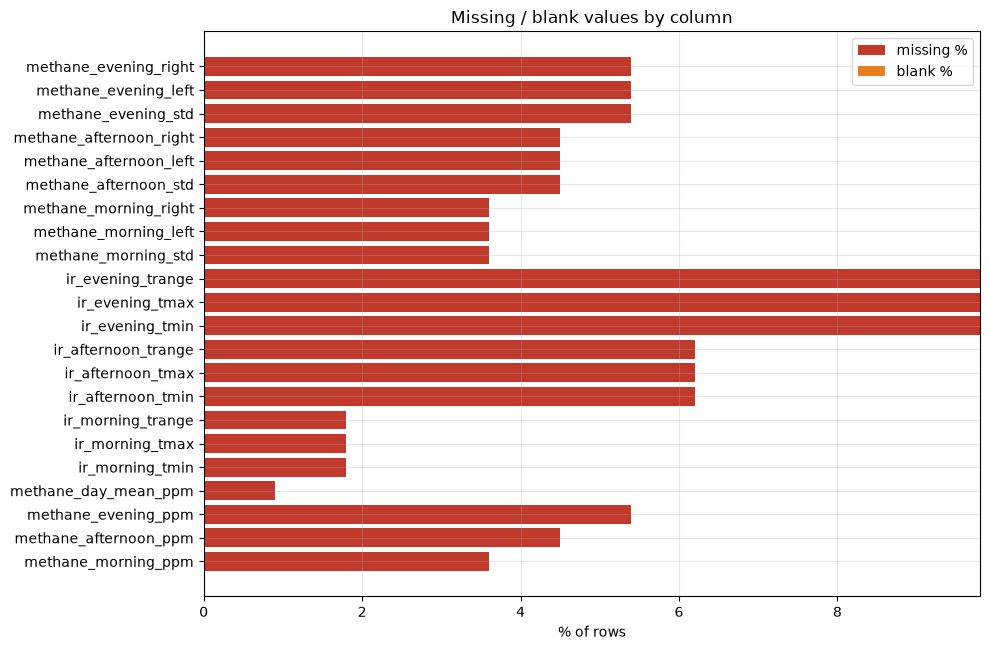

In [23]:
print("Columns:")
for c in df.columns:
    print(f"  {c}  ({df[c].dtype})")

missing_pct = (df.isna().mean() * 100).round(1)
blank_pct = (df.astype(str).apply(lambda s: (s.str.strip() == "").mean() * 100)).round(1)
overview = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing_%": missing_pct, "blank_%": blank_pct})
overview = overview[(overview["missing_%"] > 0) | (overview["blank_%"] > 0)]
overview = overview[overview.index != "notes"]
if len(overview):
    print("\nColumns with missing/blank values:")
    print(overview.sort_values("missing_%", ascending=False).to_string())
else:
    print("\nNo missing or blank values in any column.")

fig, ax = plt.subplots(figsize=(10, max(3, len(overview) * 0.3)))
if len(overview):
    ax.barh(overview.index, overview["missing_%"], color="#C0392B", label="missing %")
    ax.barh(overview.index, overview["blank_%"], left=overview["missing_%"], color="#E67E22", label="blank %")
    ax.set_xlabel("% of rows"); ax.set_title("Missing / blank values by column"); ax.legend()
else:
    ax.text(0.5, 0.5, "No missing/blank values", ha="center", va="center", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 2. Fruit / label / split distribution

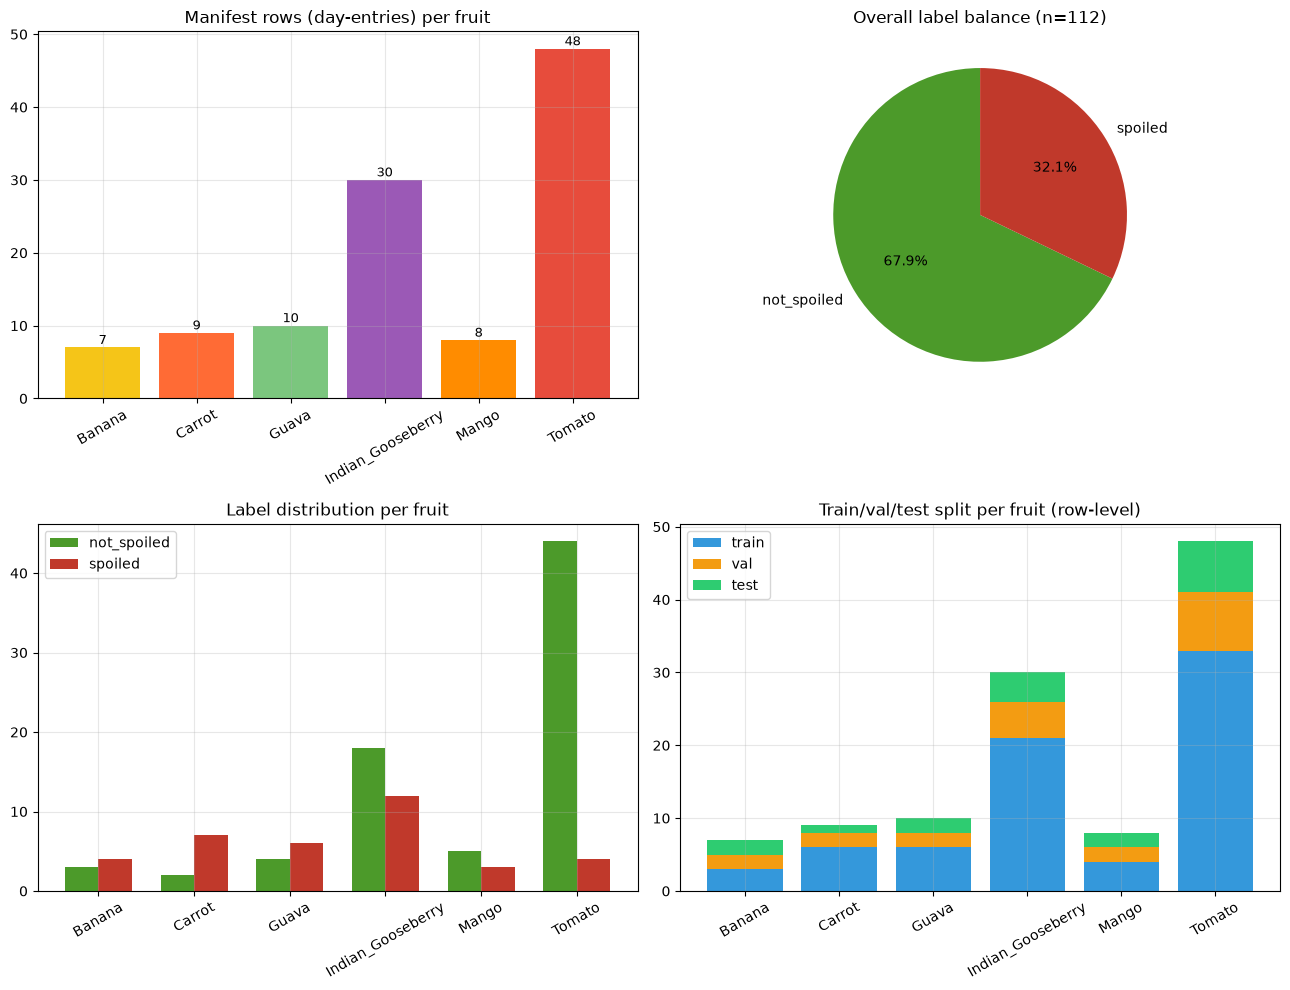

Overall balance: {'not_spoiled': np.int64(76), 'spoiled': np.int64(36)}  (32.1% minority class)


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Rows per fruit
fruit_counts = df["fruit"].value_counts().reindex(FRUIT_LIST).fillna(0)
axes[0, 0].bar(fruit_counts.index, fruit_counts.values,
               color=[FRUIT_COLORS.get(f, "#888") for f in fruit_counts.index])
axes[0, 0].set_title("Manifest rows (day-entries) per fruit")
axes[0, 0].tick_params(axis="x", rotation=30)
for i, v in enumerate(fruit_counts.values):
    axes[0, 0].text(i, v + max(fruit_counts.values) * 0.01, int(v), ha="center", fontsize=9)

# Label distribution overall
label_counts = df["label"].value_counts()
axes[0, 1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%",
               colors=[LABEL_COLORS.get(l, "#888") for l in label_counts.index], startangle=90)
axes[0, 1].set_title(f"Overall label balance (n={len(df)})")

# Label distribution per fruit
ct = pd.crosstab(df["fruit"], df["label"]).reindex(FRUIT_LIST)
x = np.arange(len(ct))
width = 0.35
for i, label in enumerate(ct.columns):
    axes[1, 0].bar(x + (i - 0.5) * width, ct[label], width, label=label,
                   color=LABEL_COLORS.get(label, "#888"))
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(ct.index, rotation=30)
axes[1, 0].set_title("Label distribution per fruit"); axes[1, 0].legend()

# Train/val/test split, per fruit (stacked)
if "split" in df.columns:
    split_ct = pd.crosstab(df["fruit"], df["split"]).reindex(FRUIT_LIST)
    split_order = [s for s in ["train", "val", "test"] if s in split_ct.columns]
    split_colors = {"train": "#3498DB", "val": "#F39C12", "test": "#2ECC71"}
    bottom = np.zeros(len(split_ct))
    for s in split_order:
        axes[1, 1].bar(split_ct.index, split_ct[s], bottom=bottom, label=s,
                       color=split_colors.get(s, "#888"))
        bottom += split_ct[s].values
    axes[1, 1].tick_params(axis="x", rotation=30)
    axes[1, 1].set_title("Train/val/test split per fruit (row-level)"); axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, "No 'split' column found", ha="center", va="center")

plt.tight_layout(); plt.show()

print(f"Overall balance: {dict(label_counts)}  "
     f"({label_counts.min()/label_counts.sum()*100:.1f}% minority class)")


## 3. Trajectory structure

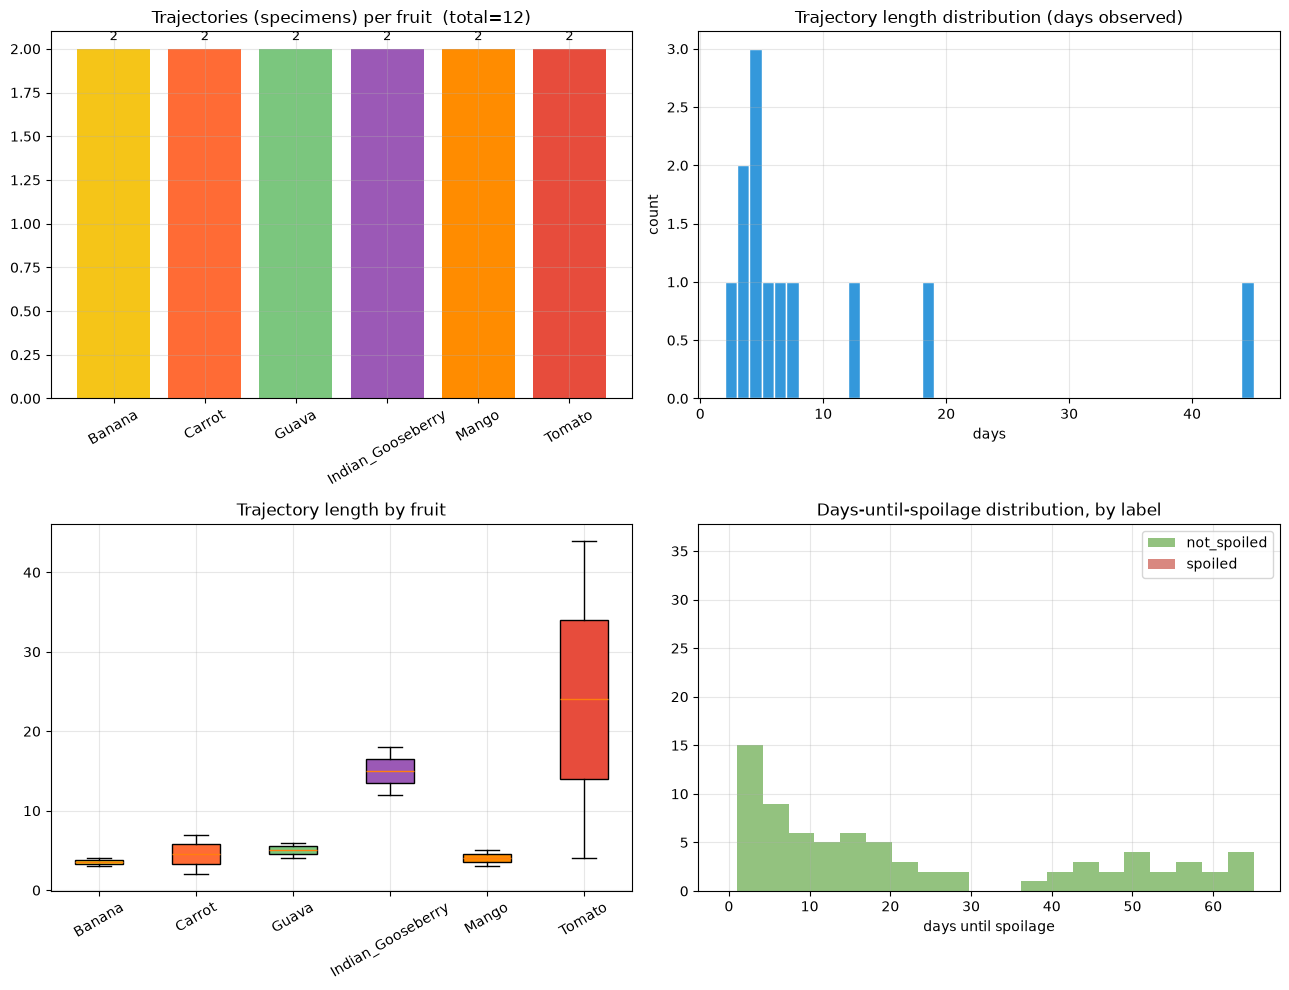

Trajectory length: mean=9.3, min=2, max=44, median=4.5


In [25]:
traj_group_cols = [c for c in ["fruit", "label"] if c in df.columns]
traj = df.groupby(traj_group_cols).agg(
    n_days=("corrected_day_index", "nunique") if "corrected_day_index" in df.columns else ("fruit", "size"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Trajectory count per fruit
traj_counts = traj["fruit"].value_counts().reindex(FRUIT_LIST).fillna(0)
axes[0, 0].bar(traj_counts.index, traj_counts.values,
               color=[FRUIT_COLORS.get(f, "#888") for f in traj_counts.index])
axes[0, 0].set_title(f"Trajectories (specimens) per fruit  (total={len(traj)})")
axes[0, 0].tick_params(axis="x", rotation=30)
for i, v in enumerate(traj_counts.values):
    axes[0, 0].text(i, v + 0.05, int(v), ha="center", fontsize=9)

# Trajectory length distribution
axes[0, 1].hist(traj["n_days"], bins=range(int(traj["n_days"].min()), int(traj["n_days"].max()) + 2),
                color="#3498DB", edgecolor="white")
axes[0, 1].set_title("Trajectory length distribution (days observed)")
axes[0, 1].set_xlabel("days"); axes[0, 1].set_ylabel("count")

# Trajectory length by fruit (boxplot)
data_by_fruit = [traj[traj["fruit"] == f]["n_days"].values for f in FRUIT_LIST if f in traj["fruit"].values]
labels_present = [f for f in FRUIT_LIST if f in traj["fruit"].values]
bp = axes[1, 0].boxplot(data_by_fruit, tick_labels=labels_present, patch_artist=True)
for patch, f in zip(bp["boxes"], labels_present):
    patch.set_facecolor(FRUIT_COLORS.get(f, "#888"))
axes[1, 0].set_title("Trajectory length by fruit"); axes[1, 0].tick_params(axis="x", rotation=30)

# Days-until-spoilage distribution
if "days_until_spoilage" in df.columns:
    dus = pd.to_numeric(df["days_until_spoilage"], errors="coerce")
    for label, color in LABEL_COLORS.items():
        vals = dus[df["label"] == label].dropna()
        if len(vals):
            axes[1, 1].hist(vals, bins=20, alpha=0.6, label=label, color=color)
    axes[1, 1].set_title("Days-until-spoilage distribution, by label")
    axes[1, 1].set_xlabel("days until spoilage"); axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, "No 'days_until_spoilage' column found", ha="center", va="center")

plt.tight_layout(); plt.show()

print(f"Trajectory length: mean={traj['n_days'].mean():.1f}, "
     f"min={traj['n_days'].min()}, max={traj['n_days'].max()}, median={traj['n_days'].median():.1f}")


## 4. Modality availability and session coverage

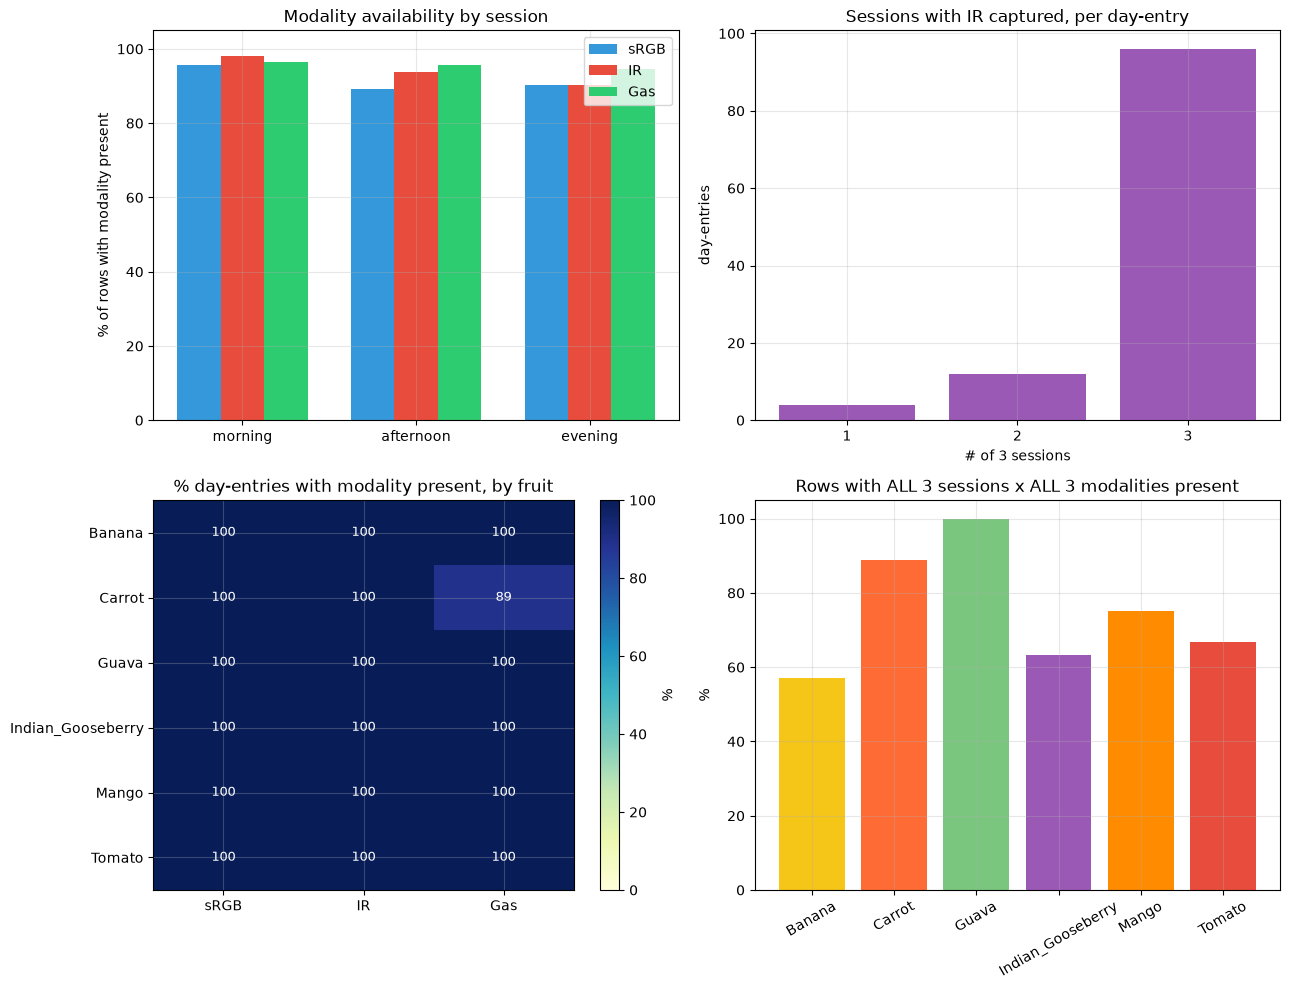

In [26]:
modality_avail = {"sRGB": [], "IR": [], "Gas": []}
for session in SESSIONS:
    if f"srgb_{session}_count" in df.columns:
        modality_avail["sRGB"].append((session, (pd.to_numeric(df[f"srgb_{session}_count"], errors="coerce").fillna(0) > 0).mean() * 100))
    if f"ir_{session}_count" in df.columns:
        modality_avail["IR"].append((session, (pd.to_numeric(df[f"ir_{session}_count"], errors="coerce").fillna(0) > 0).mean() * 100))
    if f"methane_{session}_present" in df.columns:
        modality_avail["Gas"].append((session, (df[f"methane_{session}_present"].astype(str).str.strip().str.upper() == "TRUE").mean() * 100))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Availability % per modality per session
width = 0.25
x = np.arange(len(SESSIONS))
colors = {"sRGB": "#3498DB", "IR": "#E74C3C", "Gas": "#2ECC71"}
for i, (modality, vals) in enumerate(modality_avail.items()):
    if not vals:
        continue
    y = [dict(vals).get(s, 0) for s in SESSIONS]
    axes[0, 0].bar(x + (i - 1) * width, y, width, label=modality, color=colors[modality])
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(SESSIONS)
axes[0, 0].set_ylabel("% of rows with modality present"); axes[0, 0].set_ylim(0, 105)
axes[0, 0].set_title("Modality availability by session"); axes[0, 0].legend()

# Session coverage
if all(f"ir_{s}_count" in df.columns for s in SESSIONS):
    n_sessions_ir = sum((pd.to_numeric(df[f"ir_{s}_count"], errors="coerce").fillna(0) > 0).astype(int) for s in SESSIONS)
    counts = n_sessions_ir.value_counts().sort_index()
    axes[0, 1].bar(counts.index.astype(str), counts.values, color="#9B59B6")
    axes[0, 1].set_title("Sessions with IR captured, per day-entry")
    axes[0, 1].set_xlabel("# of 3 sessions"); axes[0, 1].set_ylabel("day-entries")
else:
    axes[0, 1].text(0.5, 0.5, "IR session columns not found", ha="center", va="center")

# Modality availability heatmap
heat_rows, heat_data = [], []
for fruit in FRUIT_LIST:
    sub = df[df["fruit"] == fruit]
    row = []
    for modality, prefix, check in [
        ("sRGB", "srgb", lambda v: pd.to_numeric(v, errors="coerce").fillna(0) > 0),
        ("IR", "ir", lambda v: pd.to_numeric(v, errors="coerce").fillna(0) > 0),
        ("Gas", "methane", lambda v: v.astype(str).str.strip().str.upper() == "TRUE"),
    ]:
        cols = [f"{prefix}_{s}_count" if modality != "Gas" else f"{prefix}_{s}_present" for s in SESSIONS]
        cols = [c for c in cols if c in sub.columns]
        if not cols:
            row.append(np.nan); continue
        avail = pd.concat([check(sub[c]) for c in cols], axis=1).any(axis=1)
        row.append(avail.mean() * 100)
    heat_rows.append(fruit); heat_data.append(row)

heat_data = np.array(heat_data, dtype=float)
im = axes[1, 0].imshow(heat_data, cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
axes[1, 0].set_xticks(range(3)); axes[1, 0].set_xticklabels(["sRGB", "IR", "Gas"])
axes[1, 0].set_yticks(range(len(heat_rows))); axes[1, 0].set_yticklabels(heat_rows)
axes[1, 0].set_title("% day-entries with modality present, by fruit")
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        if not np.isnan(heat_data[i, j]):
            axes[1, 0].text(j, i, f"{heat_data[i, j]:.0f}", ha="center", va="center",
                            color="white" if heat_data[i, j] > 50 else "black", fontsize=9)
plt.colorbar(im, ax=axes[1, 0], label="%")

# All-3-modalities-present rate per fruit
if all(f"{p}_{s}_{suffix}" in df.columns for p, suffix in [("srgb", "count"), ("ir", "count"), ("methane", "present")] for s in SESSIONS):
    all3 = pd.Series(True, index=df.index)
    for s in SESSIONS:
        all3 &= (pd.to_numeric(df[f"srgb_{s}_count"], errors="coerce").fillna(0) > 0)
        all3 &= (pd.to_numeric(df[f"ir_{s}_count"], errors="coerce").fillna(0) > 0)
        all3 &= (df[f"methane_{s}_present"].astype(str).str.strip().str.upper() == "TRUE")
    rate_by_fruit = df.assign(all3=all3).groupby("fruit")["all3"].mean().reindex(FRUIT_LIST) * 100
    axes[1, 1].bar(rate_by_fruit.index, rate_by_fruit.values,
                   color=[FRUIT_COLORS.get(f, "#888") for f in rate_by_fruit.index])
    axes[1, 1].set_title("Rows with ALL 3 sessions x ALL 3 modalities present")
    axes[1, 1].set_ylabel("%"); axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


## 5. Gas-sensor distributions

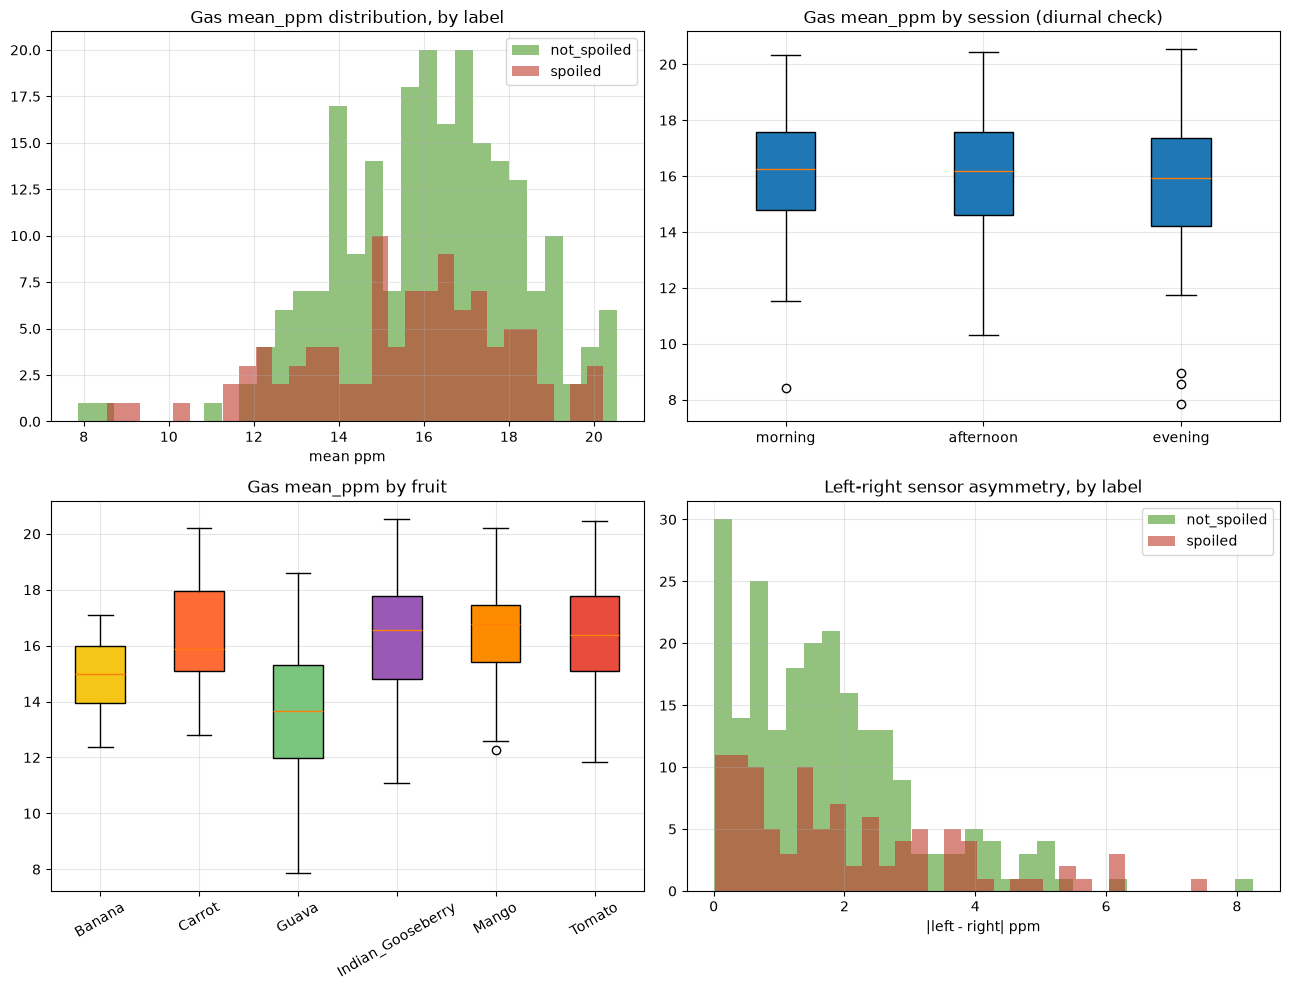

In [27]:
gas_rows = []
for session in SESSIONS:
    present_col = f"methane_{session}_present"
    if present_col not in df.columns:
        continue
    mask = df[present_col].astype(str).str.strip().str.upper() == "TRUE"
    sub = df[mask]
    for _, r in sub.iterrows():
        gas_rows.append({
            "fruit": r["fruit"], "label": r["label"], "session": session,
            "mean_ppm": pd.to_numeric(r.get(f"methane_{session}_ppm"), errors="coerce"),
            "std_ppm": pd.to_numeric(r.get(f"methane_{session}_std"), errors="coerce"),
            "left": pd.to_numeric(r.get(f"methane_{session}_left"), errors="coerce"),
            "right": pd.to_numeric(r.get(f"methane_{session}_right"), errors="coerce"),
        })
gas_df = pd.DataFrame(gas_rows).dropna(subset=["mean_ppm"])
gas_df["asymmetry"] = (gas_df["left"] - gas_df["right"]).abs()

if len(gas_df):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    for label, color in LABEL_COLORS.items():
        vals = gas_df[gas_df["label"] == label]["mean_ppm"]
        if len(vals):
            axes[0, 0].hist(vals, bins=30, alpha=0.6, label=label, color=color)
    axes[0, 0].set_title("Gas mean_ppm distribution, by label"); axes[0, 0].legend()
    axes[0, 0].set_xlabel("mean ppm")

    data_by_session = [gas_df[gas_df["session"] == s]["mean_ppm"].dropna().values for s in SESSIONS]
    axes[0, 1].boxplot(data_by_session, tick_labels=SESSIONS, patch_artist=True)
    axes[0, 1].set_title("Gas mean_ppm by session (diurnal check)")

    data_by_fruit = [gas_df[gas_df["fruit"] == f]["mean_ppm"].dropna().values for f in FRUIT_LIST if f in gas_df["fruit"].values]
    labels_present = [f for f in FRUIT_LIST if f in gas_df["fruit"].values]
    bp = axes[1, 0].boxplot(data_by_fruit, tick_labels=labels_present, patch_artist=True)
    for patch, f in zip(bp["boxes"], labels_present):
        patch.set_facecolor(FRUIT_COLORS.get(f, "#888"))
    axes[1, 0].set_title("Gas mean_ppm by fruit"); axes[1, 0].tick_params(axis="x", rotation=30)

    for label, color in LABEL_COLORS.items():
        vals = gas_df[gas_df["label"] == label]["asymmetry"].dropna()
        if len(vals):
            axes[1, 1].hist(vals, bins=30, alpha=0.6, label=label, color=color)
    axes[1, 1].set_title("Left-right sensor asymmetry, by label"); axes[1, 1].legend()
    axes[1, 1].set_xlabel("|left - right| ppm")

    plt.tight_layout(); plt.show()


## 6. IR distributions

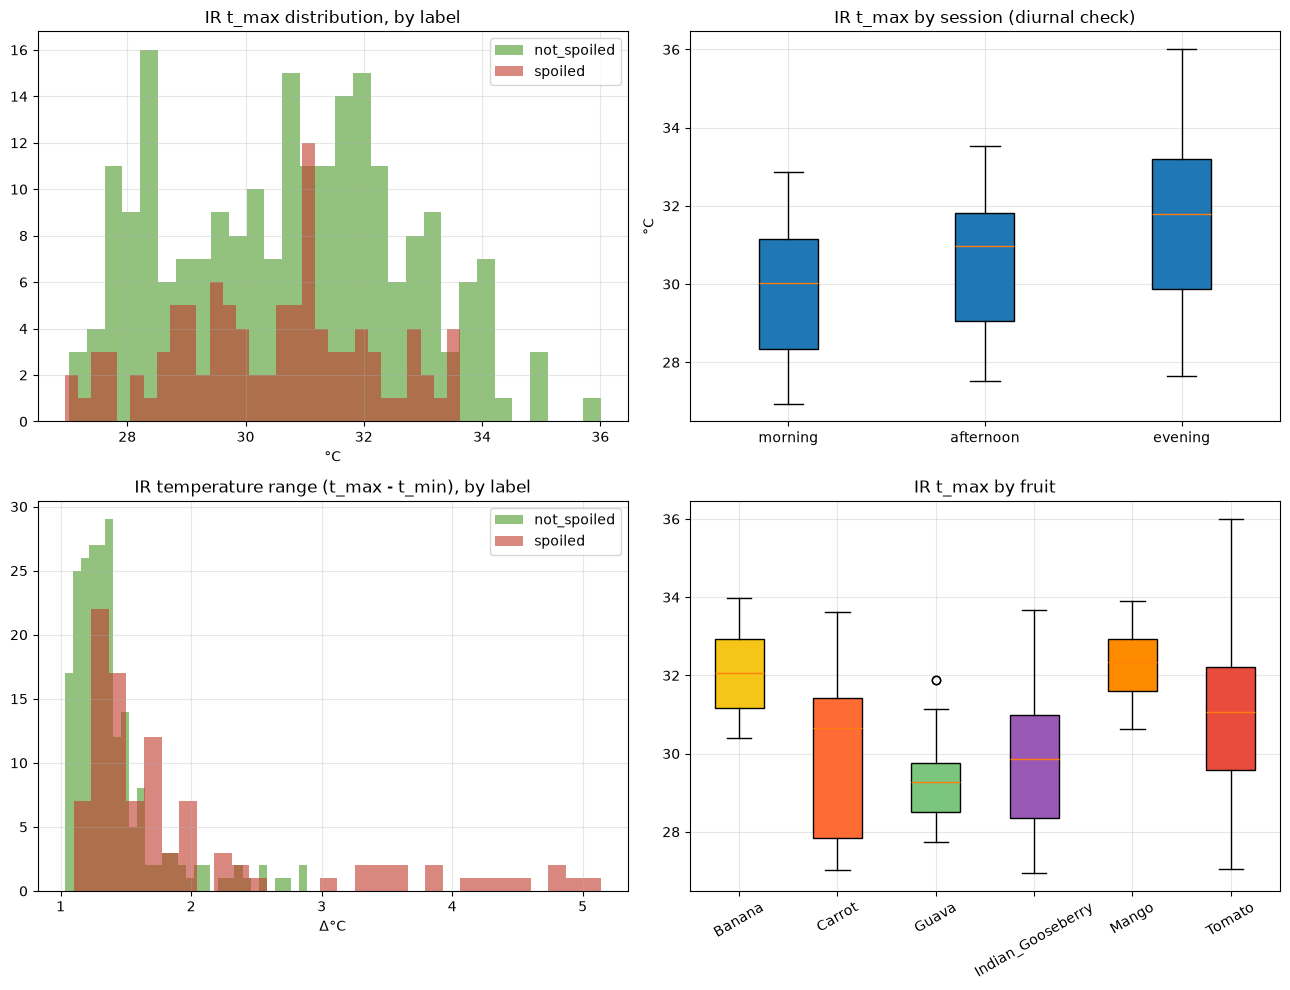

t_max spread across SESSIONS (diurnal): 1.76°C
t_max spread across LABELS (spoilage signal): 0.30°C


In [28]:
ir_rows = []
for session in SESSIONS:
    count_col = f"ir_{session}_count"
    if count_col not in df.columns:
        continue
    mask = pd.to_numeric(df[count_col], errors="coerce").fillna(0) > 0
    sub = df[mask]
    for _, r in sub.iterrows():
        ir_rows.append({
            "fruit": r["fruit"], "label": r["label"], "session": session,
            "tmin": pd.to_numeric(r.get(f"ir_{session}_tmin"), errors="coerce"),
            "tmax": pd.to_numeric(r.get(f"ir_{session}_tmax"), errors="coerce"),
            "trange": pd.to_numeric(r.get(f"ir_{session}_trange"), errors="coerce"),
        })
ir_df = pd.DataFrame(ir_rows).dropna(subset=["tmin"])

if len(ir_df):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    for label, color in LABEL_COLORS.items():
        vals = ir_df[ir_df["label"] == label]["tmax"]
        if len(vals):
            axes[0, 0].hist(vals, bins=30, alpha=0.6, label=label, color=color)
    axes[0, 0].set_title("IR t_max distribution, by label"); axes[0, 0].legend()
    axes[0, 0].set_xlabel("°C")

    data_by_session = [ir_df[ir_df["session"] == s]["tmax"].dropna().values for s in SESSIONS]
    axes[0, 1].boxplot(data_by_session, tick_labels=SESSIONS, patch_artist=True)
    axes[0, 1].set_title("IR t_max by session (diurnal check)"); axes[0, 1].set_ylabel("°C")

    for label, color in LABEL_COLORS.items():
        vals = ir_df[ir_df["label"] == label]["trange"]
        if len(vals):
            axes[1, 0].hist(vals, bins=30, alpha=0.6, label=label, color=color)
    axes[1, 0].set_title("IR temperature range (t_max - t_min), by label"); axes[1, 0].legend()
    axes[1, 0].set_xlabel("Δ°C")

    data_by_fruit = [ir_df[ir_df["fruit"] == f]["tmax"].dropna().values for f in FRUIT_LIST if f in ir_df["fruit"].values]
    labels_present = [f for f in FRUIT_LIST if f in ir_df["fruit"].values]
    bp = axes[1, 1].boxplot(data_by_fruit, tick_labels=labels_present, patch_artist=True)
    for patch, f in zip(bp["boxes"], labels_present):
        patch.set_facecolor(FRUIT_COLORS.get(f, "#888"))
    axes[1, 1].set_title("IR t_max by fruit"); axes[1, 1].tick_params(axis="x", rotation=30)

    plt.tight_layout(); plt.show()

    session_means = ir_df.groupby("session")["tmax"].mean()
    label_means = ir_df.groupby("label")["tmax"].mean()
    session_spread = session_means.max() - session_means.min()
    label_spread = abs(label_means.get("spoiled", 0) - label_means.get("not_spoiled", 0))
    print(f"t_max spread across SESSIONS (diurnal): {session_spread:.2f}°C")
    print(f"t_max spread across LABELS (spoilage signal): {label_spread:.2f}°C")


## 7. Feature correlations

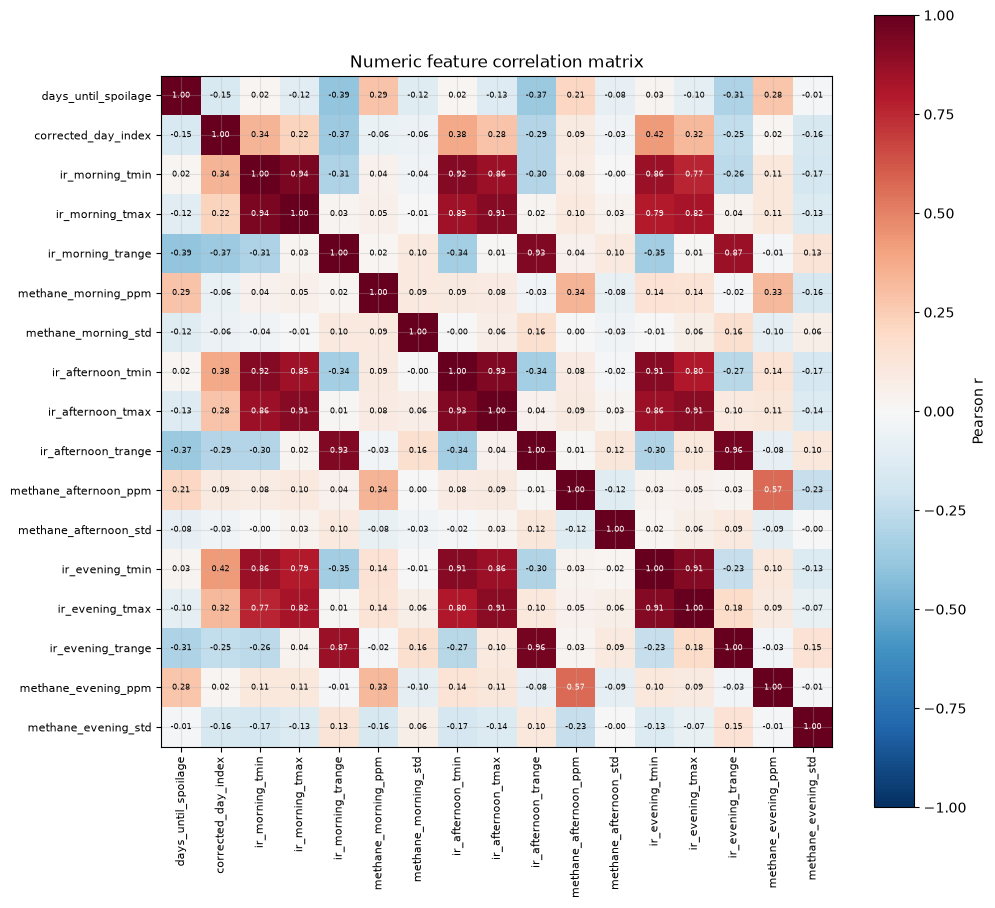

Features most correlated with days_until_spoilage:
ir_morning_trange       -0.392440
ir_afternoon_trange     -0.372110
ir_evening_trange       -0.305347
methane_morning_ppm      0.286287
methane_evening_ppm      0.276485
methane_afternoon_ppm    0.205212
corrected_day_index     -0.149641
ir_afternoon_tmax       -0.127054


In [29]:
numeric_candidates = ["days_until_spoilage", "corrected_day_index"]
for session in SESSIONS:
    numeric_candidates += [f"ir_{session}_tmin", f"ir_{session}_tmax", f"ir_{session}_trange",
                           f"methane_{session}_ppm", f"methane_{session}_std"]
numeric_cols = [c for c in numeric_candidates if c in df.columns]
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

corr = num_df.corr()
fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.6), max(7, len(numeric_cols) * 0.55)))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                   color="white" if abs(v) > 0.5 else "black", fontsize=6)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Numeric feature correlation matrix")
plt.tight_layout(); plt.show()

if "days_until_spoilage" in corr.columns:
    dus_corr = corr["days_until_spoilage"].drop("days_until_spoilage").sort_values(key=abs, ascending=False)
    print("Features most correlated with days_until_spoilage:")
    print(dus_corr.head(8).to_string())


## 8. Per-trajectory timelines

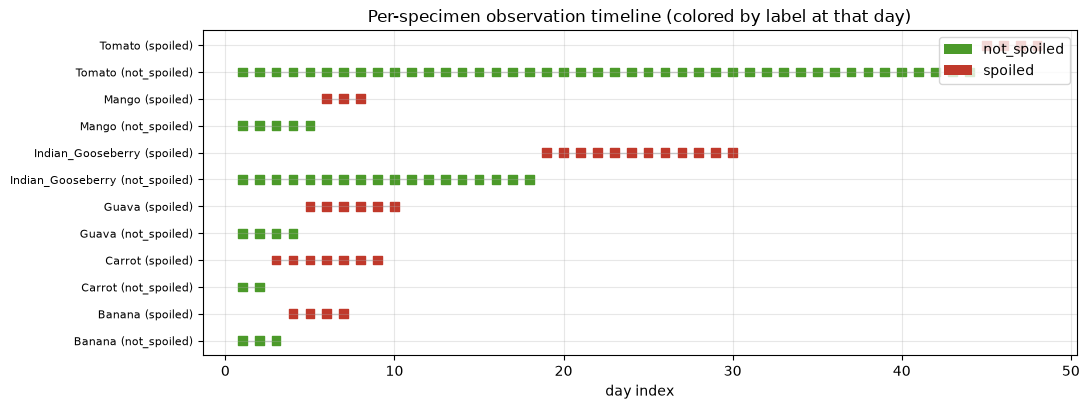

In [30]:
if "corrected_day_index" in df.columns:
    traj_ids = df[traj_group_cols + ["corrected_day_index"]].drop_duplicates()
    traj_ids = traj_ids.sort_values(traj_group_cols + ["corrected_day_index"])
    traj_ids["specimen"] = traj_ids["fruit"].astype(str) + " (" + traj_ids["label"].astype(str) + ")"

    specimens = sorted(traj_ids["specimen"].unique())
    fig, ax = plt.subplots(figsize=(11, max(4, len(specimens) * 0.35)))
    for i, spec in enumerate(specimens):
        sub = traj_ids[traj_ids["specimen"] == spec].sort_values("corrected_day_index")
        colors = [LABEL_COLORS.get(l, "#888") for l in sub["label"]]
        ax.scatter(sub["corrected_day_index"], [i] * len(sub), c=colors, s=40, marker="s")
        ax.plot(sub["corrected_day_index"], [i] * len(sub), color="#CCCCCC", zorder=0, linewidth=1)
    ax.set_yticks(range(len(specimens))); ax.set_yticklabels(specimens, fontsize=8)
    ax.set_xlabel("day index")
    ax.set_title("Per-specimen observation timeline (colored by label at that day)")
    legend_handles = [Patch(facecolor=c, label=l) for l, c in LABEL_COLORS.items()]
    ax.legend(handles=legend_handles, loc="upper right")
    plt.tight_layout(); plt.show()

## 9. Raw image counts (from disk)

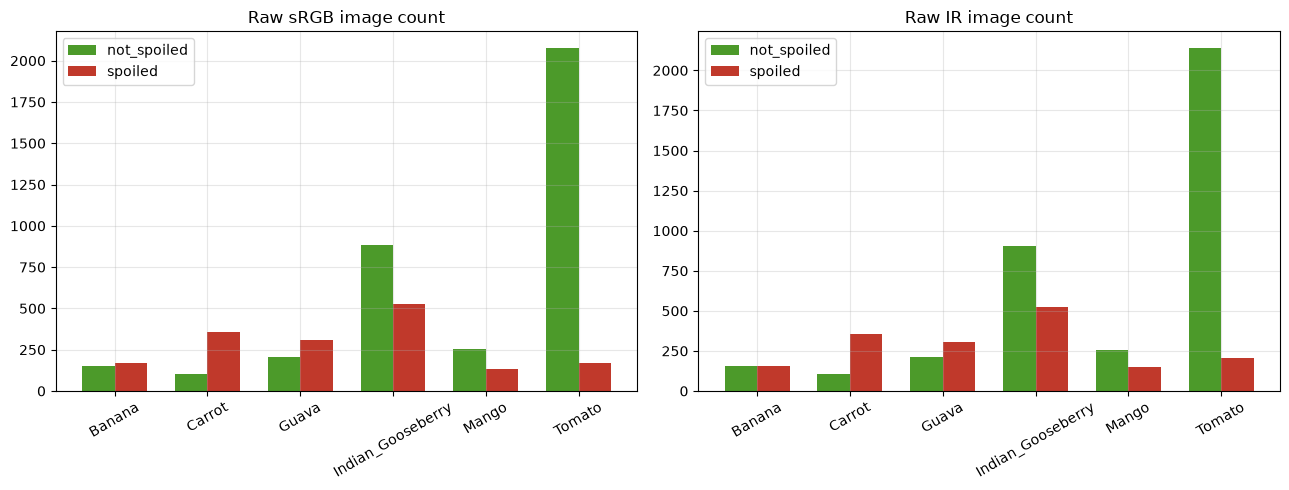

Total raw images on disk: 5338 sRGB + 5458 IR = 10796


In [31]:
def find_ir_folder(base):
    for name in ["IR_fusion_images", "IR_Fusion_images", "ir_fusion_images"]:
        p = base / name
        if p.exists():
            return p
    return base / "IR_fusion_images"

raw_counts = []
if ROOT.exists():
    label_map = {"not_spoiled": "Not_spoiled", "spoiled": "Spoiled"}
    for fruit in FRUIT_LIST:
        for label_key, label_folder in label_map.items():
            base = ROOT / "Classified" / fruit / label_folder
            rgb_dir = base / "sRGB_images"
            ir_dir = find_ir_folder(base)
            n_rgb = len(list(rgb_dir.glob("*.jpg"))) if rgb_dir.exists() else 0
            n_ir = len(list(ir_dir.glob("*.jpg"))) if ir_dir.exists() else 0
            raw_counts.append({"fruit": fruit, "label": label_key, "n_rgb": n_rgb, "n_ir": n_ir})

    raw_df = pd.DataFrame(raw_counts)
    if raw_df["n_rgb"].sum() > 0 or raw_df["n_ir"].sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        pivot_rgb = raw_df.pivot(index="fruit", columns="label", values="n_rgb").reindex(FRUIT_LIST)
        pivot_ir = raw_df.pivot(index="fruit", columns="label", values="n_ir").reindex(FRUIT_LIST)
        x = np.arange(len(FRUIT_LIST)); width = 0.35
        for i, label in enumerate(["not_spoiled", "spoiled"]):
            if label in pivot_rgb.columns:
                axes[0].bar(x + (i - 0.5) * width, pivot_rgb[label], width, label=label,
                           color=LABEL_COLORS.get(label, "#888"))
            if label in pivot_ir.columns:
                axes[1].bar(x + (i - 0.5) * width, pivot_ir[label], width, label=label,
                           color=LABEL_COLORS.get(label, "#888"))
        for ax, title in zip(axes, ["Raw sRGB image count", "Raw IR image count"]):
            ax.set_xticks(x); ax.set_xticklabels(FRUIT_LIST, rotation=30); ax.set_title(title); ax.legend()
        plt.tight_layout(); plt.show()
        print(f"Total raw images on disk: {raw_df['n_rgb'].sum()} sRGB + {raw_df['n_ir'].sum()} IR "
             f"= {raw_df['n_rgb'].sum() + raw_df['n_ir'].sum()}")


## 10. Trajectory temporal consistency (corrected_day_index + days_until_spoilage)

In [32]:
diag = df.copy()
diag["actual_date_dt"] = pd.to_datetime(diag["actual_date"].astype(str), format="%Y%m%d", errors="coerce")
diag["signed_days_from_spoilage"] = pd.to_numeric(diag["signed_days_from_spoilage"], errors="coerce")
diag["implied_date"] = diag["actual_date_dt"] + pd.to_timedelta(diag["signed_days_from_spoilage"], unit="D")

consistency_rows, transition_rows = [], []
for fruit, g in diag.groupby("fruit"):
    g = g.sort_values("actual_date_dt")
    spread = (g["implied_date"].max() - g["implied_date"].min()).days
    consistency_rows.append({"fruit": fruit, "n_rows": len(g), "spread_days": spread,
                             "consistent": spread == 0})

    spoiled_rows = g[g["label"] == "spoiled"].sort_values("actual_date_dt")
    not_spoiled_rows = g[g["label"] == "not_spoiled"].sort_values("actual_date_dt")
    if len(spoiled_rows) and len(not_spoiled_rows):
        first_spoiled_date = spoiled_rows["actual_date_dt"].iloc[0]
        last_not_spoiled_date = not_spoiled_rows["actual_date_dt"].iloc[-1]
        gap_days = (first_spoiled_date - last_not_spoiled_date).days
        onset_signed_value = spoiled_rows["signed_days_from_spoilage"].iloc[0]
        transition_rows.append({"fruit": fruit, "gap_days": gap_days,
                                "onset_signed_value": onset_signed_value,
                                "match": onset_signed_value == 0})

consistency = pd.DataFrame(consistency_rows)
transition = pd.DataFrame(transition_rows)

print("Per-fruit implied-spoilage-date consistency:")
print(consistency.to_string(index=False))
print()
print("spoiled-labeled day):")
print(transition.to_string(index=False))

Per-fruit implied-spoilage-date consistency:
            fruit  n_rows  spread_days  consistent
           Banana       7            0        True
           Carrot       9            0        True
            Guava      10            0        True
Indian_Gooseberry      30            0        True
            Mango       8            0        True
           Tomato      48            0        True

spoiled-labeled day):
            fruit  gap_days  onset_signed_value  match
           Banana         2                   0   True
           Carrot         2                   0   True
            Guava         2                   0   True
Indian_Gooseberry         1                   0   True
            Mango         3                   0   True
           Tomato         2                   0   True


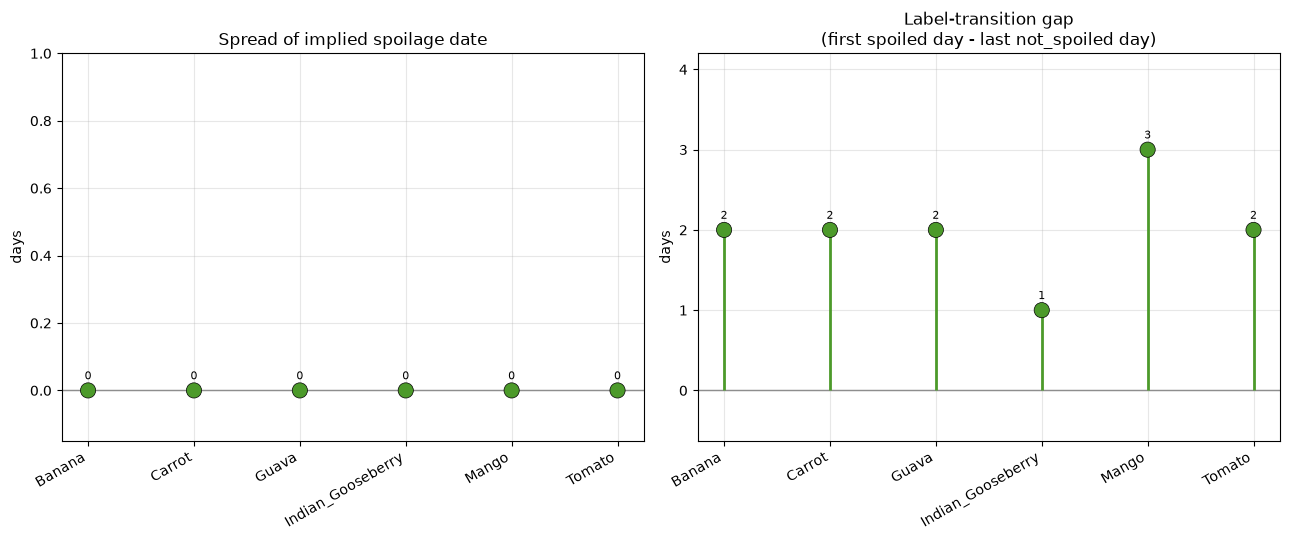

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

def plot_check(ax, x_labels, values, ok_flags, title, ylabel):
    colors = ["#4C9A2A" if ok else "#C0392B" for ok in ok_flags]
    x = np.arange(len(x_labels))
    ax.scatter(x, values, color=colors, s=120, zorder=3, edgecolor="black", linewidth=0.5)
    ax.vlines(x, 0, values, color=colors, linewidth=2, zorder=2)
    ax.axhline(0, color="gray", linewidth=1, zorder=1)
    for xi, v in zip(x, values):
        ax.annotate(f"{v:g}", (xi, v), textcoords="offset points", xytext=(0, 8),
                   ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=30, ha="right")
    span = max(1.0, max(abs(v) for v in values) * 1.4) if len(values) else 1.0
    ax.set_ylim(-span * 0.15, span)
    ax.set_title(title); ax.set_ylabel(ylabel)

plot_check(axes[0], consistency["fruit"], consistency["spread_days"], consistency["consistent"],
          "Spread of implied spoilage date", "days")
plot_check(axes[1], transition["fruit"], transition["gap_days"], transition["match"],
          "Label-transition gap\n(first spoiled day - last not_spoiled day)", "days")

plt.tight_layout(); plt.show()

n_consistent = int(consistency["consistent"].sum())

## 11. Sequence break analysis

Sequence breaks (day-entry level):
sequence_break
False    104
True       8

Overall: 7.1% of day-entries follow a sequence break.


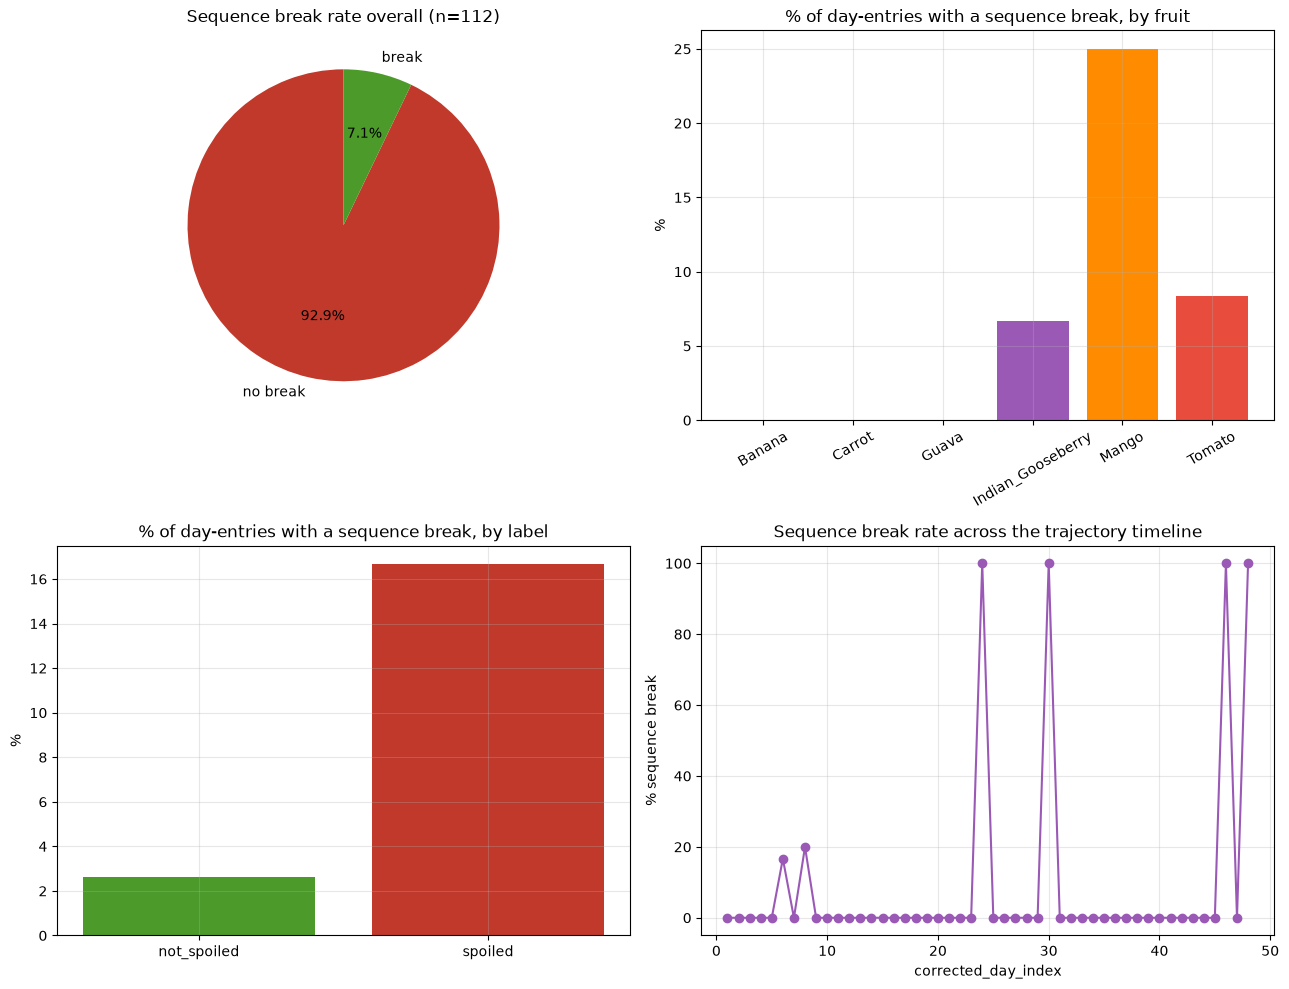


Sequence breaks by fruit (crosstab, normalized):
sequence_break     False  True 
fruit                          
Banana             1.000  0.000
Carrot             1.000  0.000
Guava              1.000  0.000
Indian_Gooseberry  0.933  0.067
Mango              0.750  0.250
Tomato             0.917  0.083


In [34]:
if "sequence_break" in df.columns:
    sb = df["sequence_break"].astype(str).str.strip().str.upper() == "TRUE"
    print("Sequence breaks (day-entry level):")
    print(sb.value_counts(dropna=False).to_string())
    print(f"\nOverall: {sb.mean()*100:.1f}% of day-entries follow a sequence break.")

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # Overall rate
    counts = sb.value_counts()
    axes[0, 0].pie(counts.values, labels=["break" if v else "no break" for v in counts.index],
                   autopct="%1.1f%%", colors=["#C0392B", "#4C9A2A"], startangle=90)
    axes[0, 0].set_title(f"Sequence break rate overall (n={len(df)})")

    # By fruit
    by_fruit = df.assign(sb=sb).groupby("fruit")["sb"].mean().reindex(FRUIT_LIST) * 100
    axes[0, 1].bar(by_fruit.index, by_fruit.values, color=[FRUIT_COLORS.get(f, "#888") for f in by_fruit.index])
    axes[0, 1].set_title("% of day-entries with a sequence break, by fruit")
    axes[0, 1].set_ylabel("%"); axes[0, 1].tick_params(axis="x", rotation=30)

    # By label
    by_label = df.assign(sb=sb).groupby("label")["sb"].mean() * 100
    axes[1, 0].bar(by_label.index, by_label.values, color=[LABEL_COLORS.get(l, "#888") for l in by_label.index])
    axes[1, 0].set_title("% of day-entries with a sequence break, by label")
    axes[1, 0].set_ylabel("%")

    # By corrected_day_index 
    if "corrected_day_index" in df.columns:
        by_day = df.assign(sb=sb).groupby("corrected_day_index")["sb"].mean() * 100
        axes[1, 1].plot(by_day.index, by_day.values, marker="o", color="#9B59B6")
        axes[1, 1].set_xlabel("corrected_day_index"); axes[1, 1].set_ylabel("% sequence break")
        axes[1, 1].set_title("Sequence break rate across the trajectory timeline")
    else:
        axes[1, 1].text(0.5, 0.5, "No corrected_day_index column found", ha="center", va="center")

    plt.tight_layout(); plt.show()

    print("\nSequence breaks by fruit (crosstab, normalized):")
    print(pd.crosstab(df["fruit"], sb, normalize="index").round(3).to_string())
else:
    print("No 'sequence_break' column found.")

## 12. Modality completeness combinations

Modality combination counts (day-entries):
combination
RGB + IR + Gas    111
RGB + IR            1

99.1% of day-entries have all 3 modalities.


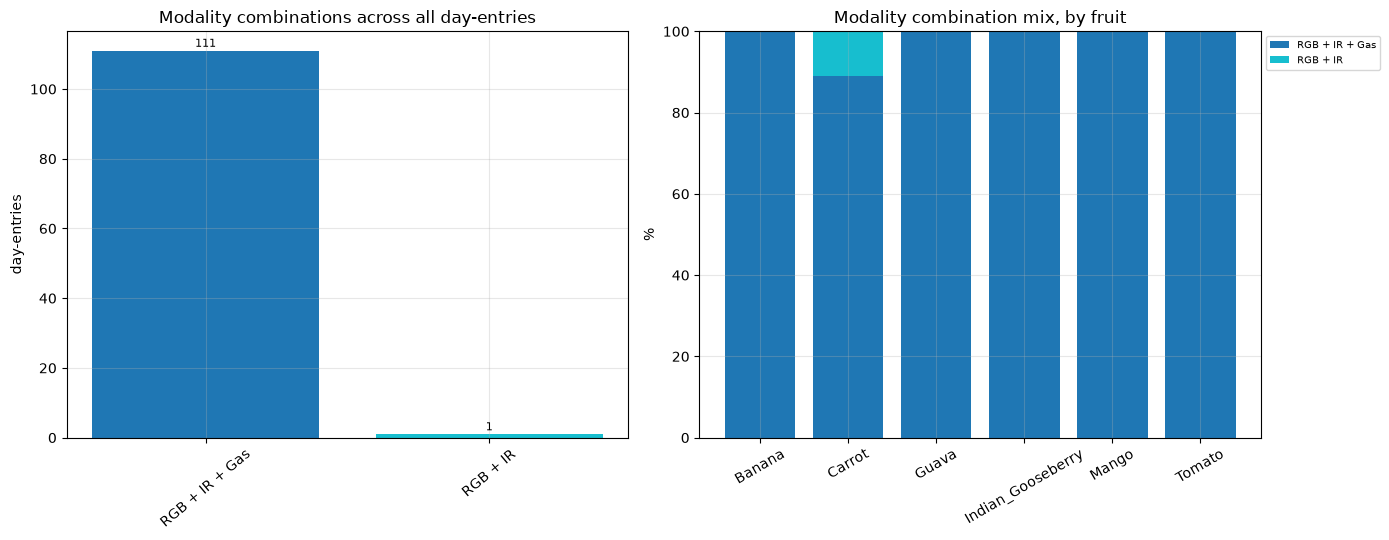

In [35]:
availability = pd.DataFrame(index=df.index)
availability["RGB"] = pd.to_numeric(df["srgb_total_sessions"], errors="coerce").fillna(0) > 0
availability["IR"]  = pd.to_numeric(df["ir_total_sessions"], errors="coerce").fillna(0) > 0
availability["Gas"] = pd.to_numeric(df["methane_total_sessions"], errors="coerce").fillna(0) > 0

availability["combination"] = availability.apply(
    lambda r: " + ".join(m for m in ["RGB", "IR", "Gas"] if r[m]) if r[["RGB", "IR", "Gas"]].any() else "None",
    axis=1,
)

combo_counts = availability["combination"].value_counts()
print("Modality combination counts (day-entries):")
print(combo_counts.to_string())
print(f"\n{(availability['combination'] == 'RGB + IR + Gas').mean()*100:.1f}% of day-entries have all 3 modalities.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

combo_order = combo_counts.sort_values(ascending=False)
combo_colors = plt.cm.tab10(np.linspace(0, 1, len(combo_order)))
axes[0].bar(combo_order.index, combo_order.values, color=combo_colors)
axes[0].set_title("Modality combinations across all day-entries")
axes[0].set_ylabel("day-entries"); axes[0].tick_params(axis="x", rotation=40)
for i, v in enumerate(combo_order.values):
    axes[0].text(i, v + max(combo_order.values) * 0.01, int(v), ha="center", fontsize=8)

combo_by_fruit = pd.crosstab(df["fruit"], availability["combination"], normalize="index").reindex(FRUIT_LIST) * 100
combo_by_fruit = combo_by_fruit[combo_order.index]  # keep same combo order/colors as left plot
bottom = np.zeros(len(combo_by_fruit))
for combo, color in zip(combo_by_fruit.columns, combo_colors):
    axes[1].bar(combo_by_fruit.index, combo_by_fruit[combo], bottom=bottom, label=combo, color=color)
    bottom += combo_by_fruit[combo].values
axes[1].set_title("Modality combination mix, by fruit")
axes[1].set_ylabel("%"); axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))

plt.tight_layout(); plt.show()

## 13. Modality availability by degradation label

Modality availability (%) by label:
             has_rgb  has_ir  has_gas
label                                
not_spoiled    100.0   100.0    100.0
spoiled        100.0   100.0     97.2


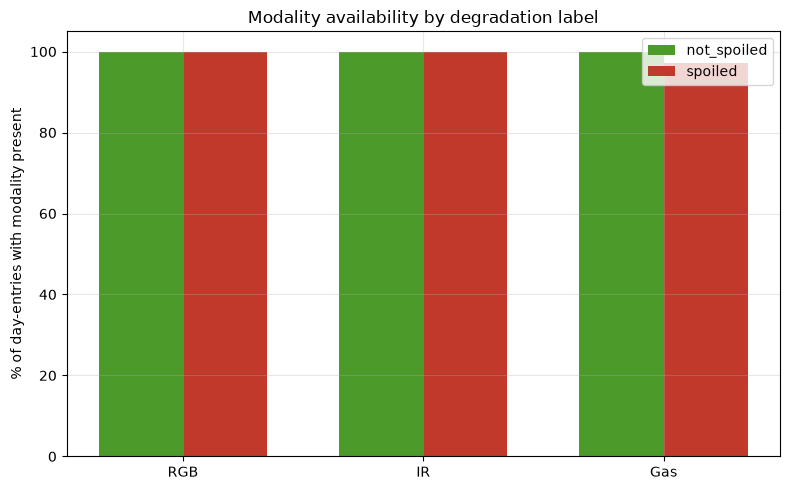


spoiled - not_spoiled gap (percentage points):
has_rgb    0.0
has_ir     0.0
has_gas   -2.8


In [36]:
tmp = df.copy()
tmp["has_rgb"] = pd.to_numeric(tmp["srgb_total_sessions"], errors="coerce").fillna(0) > 0
tmp["has_ir"]  = pd.to_numeric(tmp["ir_total_sessions"], errors="coerce").fillna(0) > 0
tmp["has_gas"] = pd.to_numeric(tmp["methane_total_sessions"], errors="coerce").fillna(0) > 0

availability_by_label = tmp.groupby("label")[["has_rgb", "has_ir", "has_gas"]].mean() * 100
print("Modality availability (%) by label:")
print(availability_by_label.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
modality_names = ["RGB", "IR", "Gas"]
for i, label in enumerate(availability_by_label.index):
    ax.bar(x + (i - 0.5) * width, availability_by_label.loc[label].values, width,
          label=label, color=LABEL_COLORS.get(label, "#888"))
ax.set_xticks(x); ax.set_xticklabels(modality_names)
ax.set_ylabel("% of day-entries with modality present"); ax.set_ylim(0, 105)
ax.set_title("Modality availability by degradation label")
ax.legend()
plt.tight_layout(); plt.show()

gap = (availability_by_label.loc["spoiled"] - availability_by_label.loc["not_spoiled"]) if \
      {"spoiled", "not_spoiled"}.issubset(availability_by_label.index) else None
if gap is not None:
    print("\nspoiled - not_spoiled gap (percentage points):")
    print(gap.round(1).to_string())
    if gap.abs().max() > 5:
        print("\nNotable gap -- missingness is not evenly spread across degradation stages, "
             "supporting the missing-not-at-random assumption behind the GRU-D gas encoder design.")

## 14. Days-until-spoilage by fruit

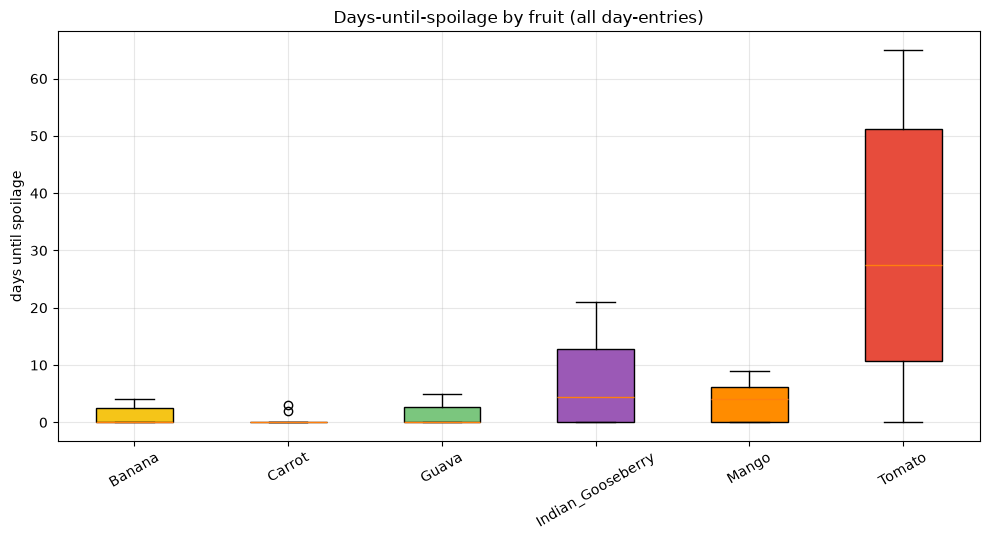

                   mean   std  min  max
fruit                                  
Banana              1.3   1.7    0    4
Carrot              0.6   1.1    0    3
Guava               1.4   2.0    0    5
Indian_Gooseberry   6.7   7.3    0   21
Mango               3.8   3.5    0    9
Tomato             31.3  22.0    0   65


In [37]:
fig, ax = plt.subplots(figsize=(10, 5.5))
dus = pd.to_numeric(df["days_until_spoilage"], errors="coerce")
data_by_fruit = [dus[df["fruit"] == f].dropna().values for f in FRUIT_LIST if f in df["fruit"].values]
labels_present = [f for f in FRUIT_LIST if f in df["fruit"].values]
bp = ax.boxplot(data_by_fruit, tick_labels=labels_present, patch_artist=True)
for patch, f in zip(bp["boxes"], labels_present):
    patch.set_facecolor(FRUIT_COLORS.get(f, "#888"))
ax.set_ylabel("days until spoilage"); ax.set_title("Days-until-spoilage by fruit (all day-entries)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

by_fruit_stats = df.assign(dus=dus).groupby("fruit")["dus"].agg(["mean", "std", "min", "max"]).reindex(FRUIT_LIST)
print(by_fruit_stats.round(1).to_string())

## 15. Outlier analysis (continuous sensor variables)

                feature   n  outliers  outlier_%
      ir_morning_trange 110        19      17.27
    ir_afternoon_trange 105        14      13.33
        ir_t_range_mean 112        14      12.50
      ir_evening_trange 101        11      10.89
    methane_evening_std 106         3       2.83
    methane_evening_ppm 106         3       2.83
  methane_afternoon_std 107         3       2.80
  methane_morning_right 108         3       2.78
    methane_morning_std 108         3       2.78
   methane_evening_left 106         2       1.89
  methane_evening_right 106         2       1.89
methane_afternoon_right 107         2       1.87
   methane_morning_left 108         1       0.93
 methane_afternoon_left 107         1       0.93
    methane_morning_ppm 108         1       0.93
      ir_afternoon_tmax 105         0       0.00
          ir_t_max_mean 112         0       0.00
        ir_evening_tmin 101         0       0.00
        ir_evening_tmax 101         0       0.00
      ir_afternoon_t

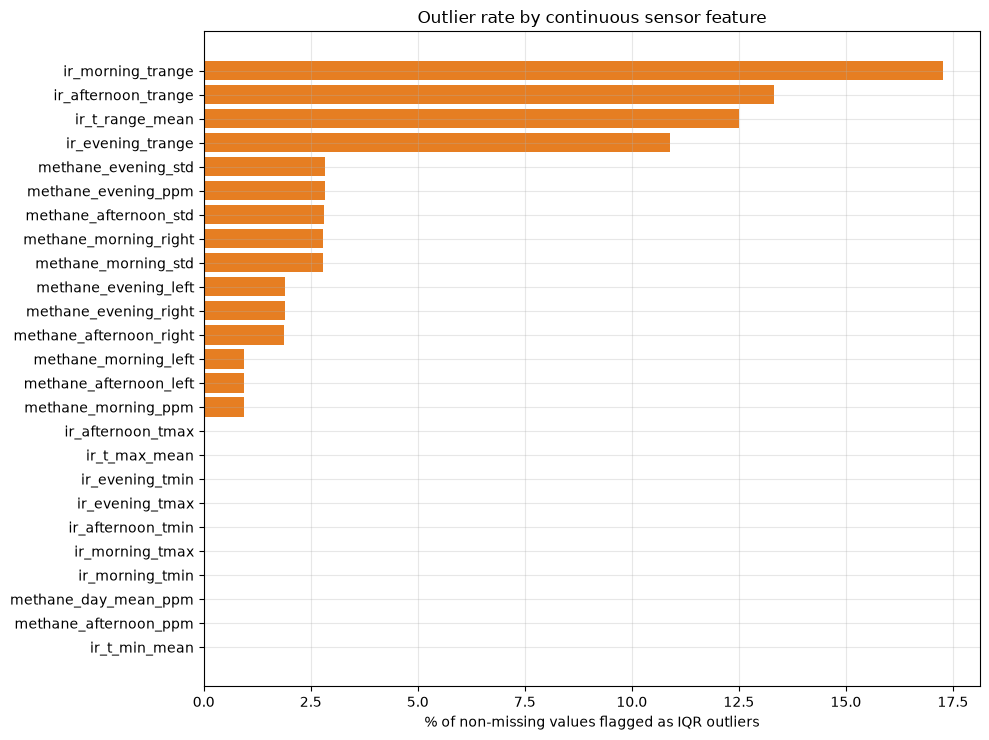

            feature   n  outliers  outlier_%
  ir_morning_trange 110        19      17.27
ir_afternoon_trange 105        14      13.33
    ir_t_range_mean 112        14      12.50
  ir_evening_trange 101        11      10.89


In [38]:
sensor_cols = [
    c for c in df.columns
    if (c.startswith("methane_") or c.startswith("ir_"))
    and pd.api.types.is_float_dtype(df[c])
]

outlier_summary = []
for c in sensor_cols:
    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((s < lower) | (s > upper)).sum())
    outlier_summary.append({"feature": c, "n": len(s), "outliers": n_outliers,
                            "outlier_%": round(100 * n_outliers / len(s), 2)})

outliers = pd.DataFrame(outlier_summary).sort_values("outlier_%", ascending=False)
print(outliers.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, max(4, len(outliers) * 0.3)))
ax.barh(outliers["feature"], outliers["outlier_%"], color="#E67E22")
ax.set_xlabel("% of non-missing values flagged as IQR outliers")
ax.set_title("Outlier rate by continuous sensor feature")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

top_offenders = outliers[outliers["outlier_%"] > 5]
if len(top_offenders):
    print(top_offenders.to_string(index=False))
else:
    print("\nNo feature exceeds 5% IQR outliers.")

## 16. Specimen Boundary Check

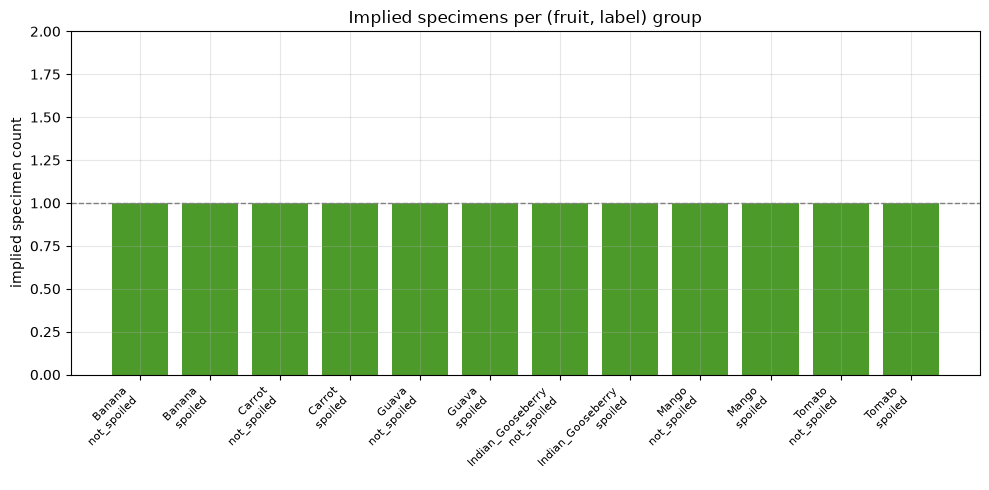

In [39]:
diag = df.copy()
diag["actual_date"] = pd.to_numeric(diag["actual_date"], errors="coerce")
diag["local_day_index"] = pd.to_numeric(diag["local_day_index"], errors="coerce")
diag = diag.sort_values(["fruit", "label", "actual_date"])

restart_rows = []
implied_rows = []
for (fruit, label), g in diag.groupby(["fruit", "label"]):
    g = g.sort_values("actual_date").reset_index(drop=True)
    local_idx = g["local_day_index"].values
    resets = np.where(np.diff(local_idx) < 0)[0] + 1
    for r in resets:
        restart_rows.append({"fruit": fruit, "label": label, "row_idx_in_group": int(r),
                             "local_day_index_before": int(g["local_day_index"].iloc[r - 1]),
                             "local_day_index_after": int(g["local_day_index"].iloc[r])})
    implied_rows.append({"fruit": fruit, "label": label, "implied_n_specimens": 1 + len(resets)})

restarts = pd.DataFrame(restart_rows)
implied = pd.DataFrame(implied_rows)

fig, ax = plt.subplots(figsize=(10, 5))
tick_labels = [f"{r.fruit}\n{r.label}" for r in implied.itertuples()]
colors = ["#4C9A2A" if n == 1 else "#C0392B" for n in implied["implied_n_specimens"]]
ax.bar(range(len(implied)), implied["implied_n_specimens"], color=colors)
ax.set_xticks(range(len(implied))); ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("implied specimen count"); ax.set_ylim(0, max(2, implied["implied_n_specimens"].max() + 1))
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title("Implied specimens per (fruit, label) group")
plt.tight_layout(); plt.show()

## 17. Days-until-Spoilage Trajectory

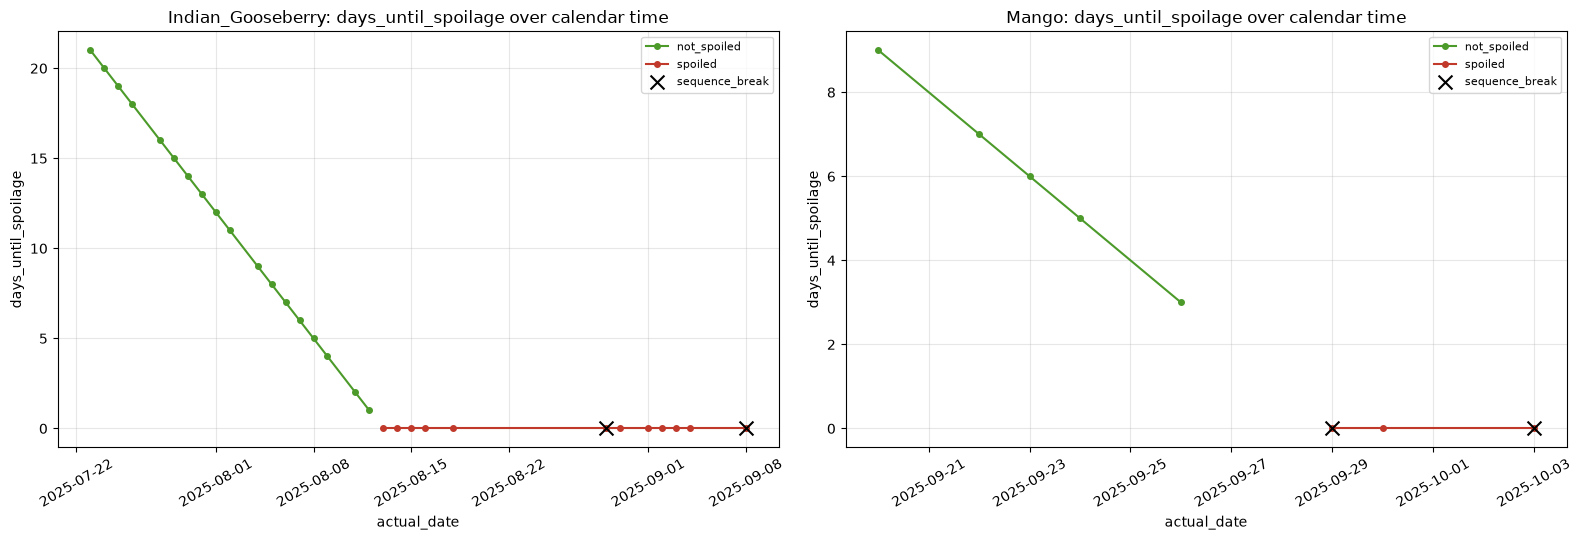

In [40]:
example_fruits = [f for f in FRUIT_LIST if df[(df["fruit"] == f) & (df["sequence_break"].astype(str).str.upper() == "TRUE")].shape[0] > 0][:2]
if not example_fruits:
    example_fruits = FRUIT_LIST[:2]

fig, axes = plt.subplots(1, len(example_fruits), figsize=(8 * len(example_fruits), 5.5), squeeze=False)
axes = axes[0]

for ax, fruit in zip(axes, example_fruits):
    g = df[df["fruit"] == fruit].copy()
    g["actual_date_dt"] = pd.to_datetime(g["actual_date"].astype(str), format="%Y%m%d", errors="coerce")
    g["days_until_spoilage"] = pd.to_numeric(g["days_until_spoilage"], errors="coerce")
    g = g.sort_values("actual_date_dt")
    g_sb = g[g["sequence_break"].astype(str).str.strip().str.upper() == "TRUE"]

    for label, color in LABEL_COLORS.items():
        sub = g[g["label"] == label]
        if len(sub):
            ax.plot(sub["actual_date_dt"], sub["days_until_spoilage"], marker="o", markersize=4,
                   color=color, label=label, linewidth=1.5)
    if len(g_sb):
        ax.scatter(g_sb["actual_date_dt"], g_sb["days_until_spoilage"], marker="x", s=100,
                  color="black", zorder=5, label="sequence_break")

    ax.set_title(f"{fruit}: days_until_spoilage over calendar time")
    ax.set_xlabel("actual_date"); ax.set_ylabel("days_until_spoilage")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 18. Sample Image Gallery

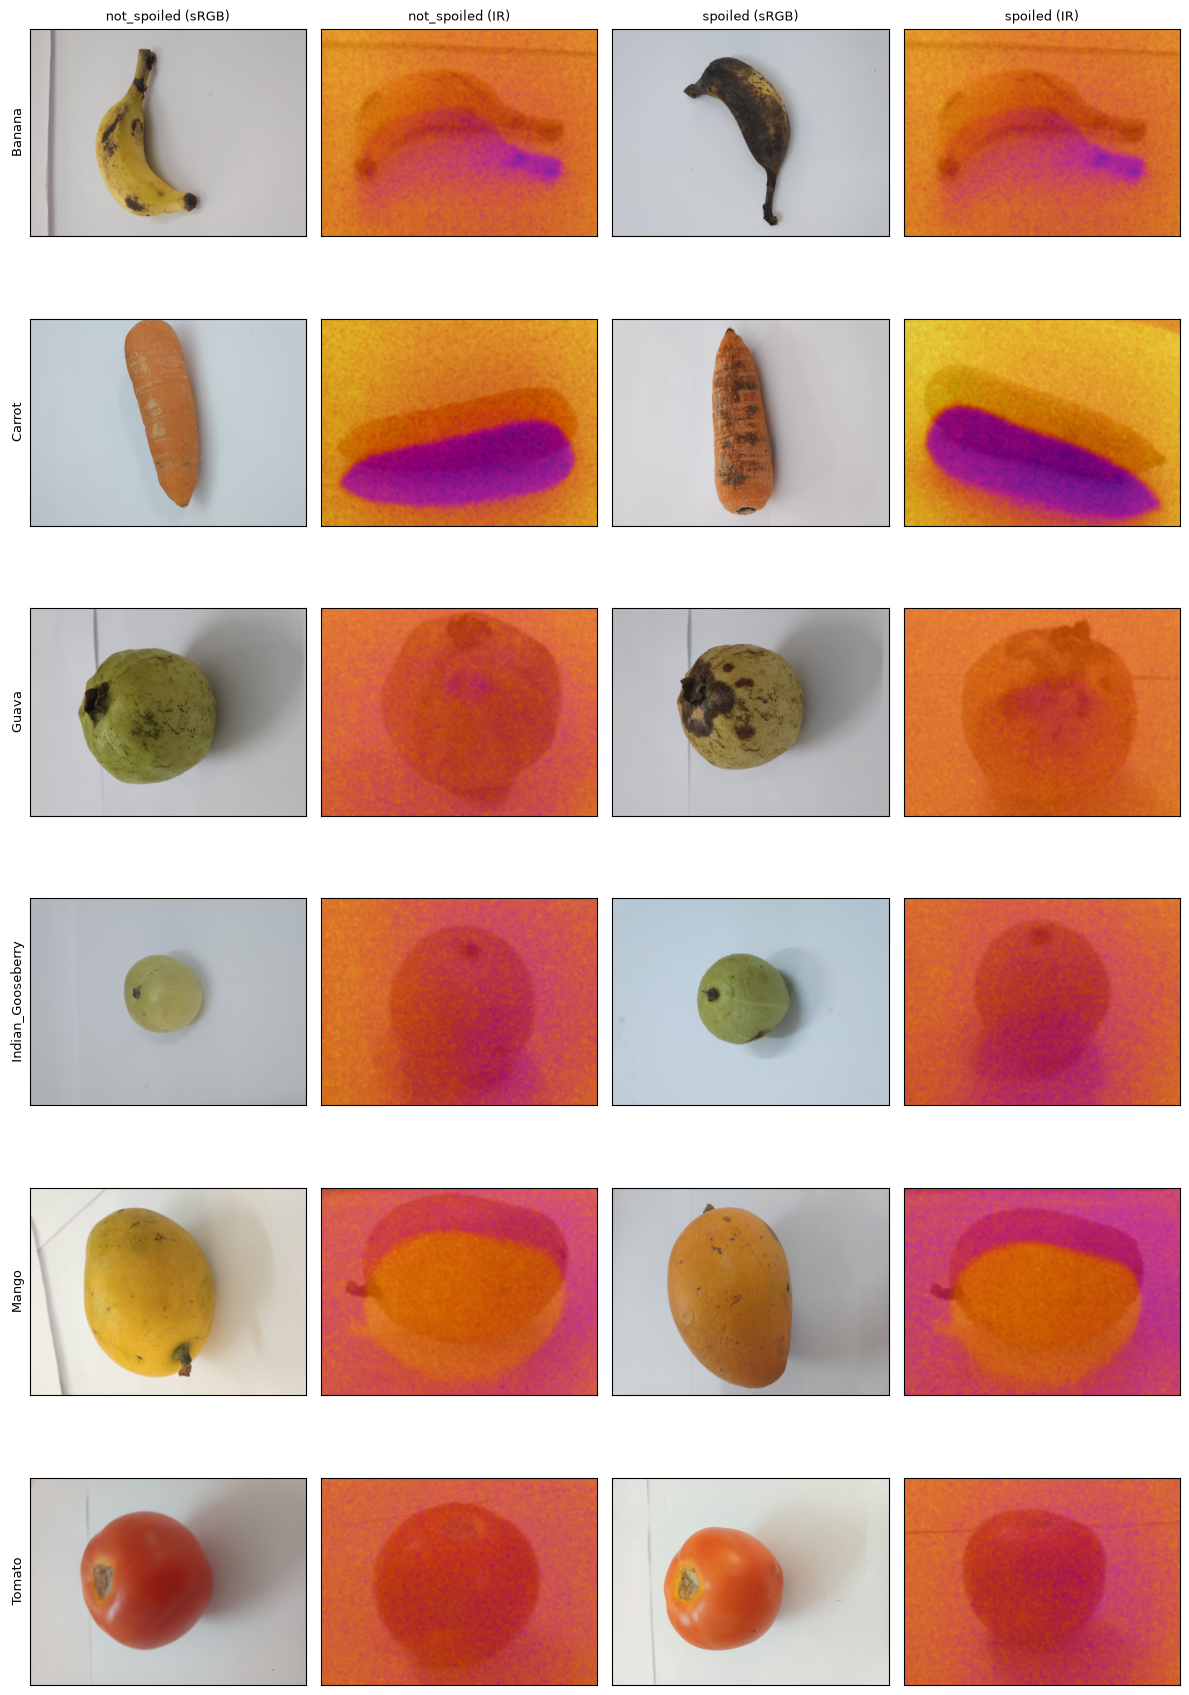

In [41]:
def sample_image_pair(fruit, label_folder):
    base = ROOT / "Classified" / fruit / label_folder
    rgb_dir, ir_dir = base / "sRGB_images", find_ir_folder(base)
    rgb_files = sorted(rgb_dir.glob("*.jpg")) if rgb_dir.exists() else []
    ir_files = sorted(ir_dir.glob("*.jpg")) if ir_dir.exists() else []
    rgb_img = Image.open(rgb_files[len(rgb_files) // 2]).convert("RGB") if rgb_files else None
    ir_img = Image.open(ir_files[len(ir_files) // 2]).convert("RGB") if ir_files else None
    return rgb_img, ir_img


if ROOT.exists():
    label_folders = ["Not_spoiled", "Spoiled"]
    fig, axes = plt.subplots(len(FRUIT_LIST), 4, figsize=(12, 3 * len(FRUIT_LIST)))
    col_titles = ["not_spoiled (sRGB)", "not_spoiled (IR)", "spoiled (sRGB)", "spoiled (IR)"]
    any_image_found = False
    for row, fruit in enumerate(FRUIT_LIST):
        col = 0
        for label_folder in label_folders:
            rgb_img, ir_img = sample_image_pair(fruit, label_folder)
            for img in (rgb_img, ir_img):
                ax = axes[row, col]
                if img is not None:
                    ax.imshow(img); any_image_found = True
                else:
                    ax.text(0.5, 0.5, "not found", ha="center", va="center", fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
                if row == 0:
                    ax.set_title(col_titles[col], fontsize=9)
                if col == 0:
                    ax.set_ylabel(fruit, fontsize=9)
                col += 1
    plt.tight_layout()
    if any_image_found:
        plt.show()
    else:
        plt.close(fig)

## 19. Summary Table

In [42]:
summary_rows = []
for fruit in FRUIT_LIST:
    sub = df[df["fruit"] == fruit]
    traj_sub = traj[traj["fruit"] == fruit]
    row = {
        "Fruit": fruit,
        "Day-entries": len(sub),
        "Trajectories": len(traj_sub),
        "Mean traj. length (days)": round(traj_sub["n_days"].mean(), 1) if len(traj_sub) else None,
        "not_spoiled": int((sub["label"] == "not_spoiled").sum()),
        "spoiled": int((sub["label"] == "spoiled").sum()),
    }
    if "split" in df.columns:
        for s in ["train", "val", "test"]:
            row[f"split={s}"] = int((sub["split"] == s).sum())
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
totals = summary_df.drop(columns=["Fruit", "Mean traj. length (days)"]).sum(numeric_only=True)
totals["Fruit"] = "TOTAL"
totals["Mean traj. length (days)"] = round(traj["n_days"].mean(), 1)
summary_df = pd.concat([summary_df, pd.DataFrame([totals])], ignore_index=True)

print(summary_df.to_string(index=False))
print()
print(f"Dataset: {len(FRUIT_LIST)} fruit/vegetable types, {len(traj)} total trajectories, "
     f"{len(df)} total day-entries.")
print(f"Class balance: {(df['label'] == 'spoiled').mean() * 100:.1f}% spoiled / "
     f"{(df['label'] == 'not_spoiled').mean() * 100:.1f}% not_spoiled overall.")


            Fruit  Day-entries  Trajectories  Mean traj. length (days)  not_spoiled  spoiled  split=train  split=val  split=test
           Banana            7             2                       3.5            3        4            3          2           2
           Carrot            9             2                       4.5            2        7            6          2           1
            Guava           10             2                       5.0            4        6            6          2           2
Indian_Gooseberry           30             2                      15.0           18       12           21          5           4
            Mango            8             2                       4.0            5        3            4          2           2
           Tomato           48             2                      24.0           44        4           33          8           7
            TOTAL          112            12                       9.3           76       36     